Fetching MNIST data...
Dataset sampled to: X=(70000, 784), y=(70000,)


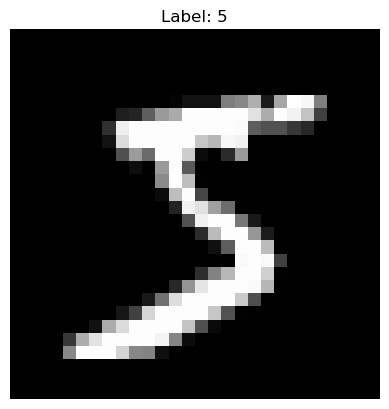

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print("Fetching MNIST data...")
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

X = X[:70000] / 255.0 
y = y[:70000].astype(np.int64)

print(f"Dataset sampled to: X={X.shape}, y={y.shape}")




plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

In [16]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC


LOKY_MAX_CPU_COUNT = '10'

base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=11)), 
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)), 
    ('log_reg', LogisticRegression(max_iter=3000)), 
    ('dt', DecisionTreeClassifier(max_depth=15, random_state=42)), 
    ('nb', GaussianNB()),
    ('l_svc', LinearSVC(dual=False, random_state=42, max_iter=3000))
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=3000), 
    cv=3,
    n_jobs=1 
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training Stacking Classifier .... ")

stacking_model.fit(X_train, y_train)
print("Training complete!")

Training Stacking Classifier .... 
Training complete!


Stacking Classifier testing Accuracy: 97.72%
Stacking Classifier train Accuracy: 99.90%

Classification Report training:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4845
           1       1.00      1.00      1.00      5513
           2       1.00      1.00      1.00      4857
           3       1.00      1.00      1.00      4965
           4       1.00      1.00      1.00      4888
           5       1.00      1.00      1.00      4398
           6       1.00      1.00      1.00      4788
           7       1.00      1.00      1.00      5045
           8       1.00      1.00      1.00      4833
           9       1.00      1.00      1.00      4868

    accuracy                           1.00     49000
   macro avg       1.00      1.00      1.00     49000
weighted avg       1.00      1.00      1.00     49000


Classification Report testing:
              precision    recall  f1-score   support

           0       0.99      0.99

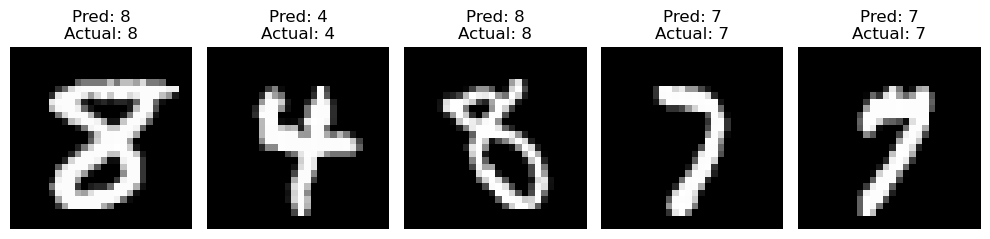

In [10]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_test = stacking_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)

print(f"Stacking Classifier testing Accuracy: {accuracy * 100:.2f}%")

y_pred_train = stacking_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred_train)

print(f"Stacking Classifier train Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report training:")
print(classification_report(y_train, y_pred_train))
print("\nClassification Report testing:")
print(classification_report(y_test, y_pred_test))



plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {y_pred_test[i]}\nActual: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


Processing 5 images...


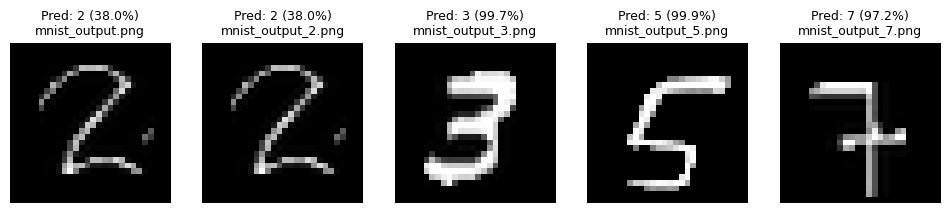

In [14]:
import os
from PIL import Image, ImageOps
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

def get_best_shift(img):
    cy, cx = ndimage.center_of_mass(img)
    rows, cols = img.shape
    shiftx = np.round(cols / 2.0 - cx).astype(int)
    shifty = np.round(rows / 2.0 - cy).astype(int)
    return shiftx, shifty

def shift(img, sx, sy):
    rows, cols = img.shape
    shifted = np.zeros_like(img)
    if sx >= 0 and sy >= 0:
        shifted[sy:, sx:] = img[: rows - sy, : cols - sx]
    elif sx < 0 and sy >= 0:
        shifted[sy:, : cols + sx] = img[: rows - sy, -sx:]
    elif sx >= 0 and sy < 0:
        shifted[: rows + sy, sx:] = img[-sy:, : cols - sx]
    elif sx < 0 and sy < 0:
        shifted[: rows + sy, : cols + sx] = img[-sy:, -sx:]
    return shifted

def preprocess_mnist_image(img_path):
    img = Image.open(img_path).convert("L")
    img = ImageOps.autocontrast(img)
    if np.mean(img) > 127:
        img = ImageOps.invert(img)
    img = img.point(lambda p: p if p > 120 else 0)

    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)
        w, h = img.size
        ratio = 20.0 / max(w, h)
        new_size = (int(w * ratio), int(h * ratio))
        img = img.resize(new_size, Image.Resampling.LANCZOS)
        new_img = Image.new("L", (28, 28), 0)
        new_img.paste(img, ((28 - new_size[0]) // 2, (28 - new_size[1]) // 2))
        img_array = np.array(new_img)
        sx, sy = get_best_shift(img_array)
        img_array = shift(img_array, sx, sy)
    else:
        img_array = np.array(img.resize((28, 28)))

    img_array = img_array.astype("float32") / 255.0
    return img_array

# --- Execution ---
data_dir = "." 
image_extensions = (".jpg", ".png", ".jpeg")
image_files = [f for f in os.listdir(data_dir) if f.endswith(image_extensions)]

if image_files:
    n = len(image_files)
    cols = min(n, 5) # Show up to 5 images per row
    rows = (n + cols - 1) // cols
    
    # Reduced figsize for smaller images and increased vertical spacing (hspace)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows), squeeze=False)
    plt.subplots_adjust(hspace=0.6) # Add space between rows to prevent overlap
    axes = axes.flatten()

    print(f"\nProcessing {n} images...")
    for i, filename in enumerate(image_files):
        img_path = os.path.join(data_dir, filename)
        try:
            img_array = preprocess_mnist_image(img_path)
            img_flat = img_array.reshape(1, -1)
            probs = stacking_model.predict_proba(img_flat)[0]
            prediction = np.argmax(probs)
            confidence = np.max(probs)

            axes[i].imshow(img_array, cmap="gray")
            # Slightly smaller title font to keep it clean
            axes[i].set_title(f"Pred: {prediction} ({confidence:.1%})\n{filename}", fontsize=9)
            axes[i].axis("off")
        except Exception as e:
            print(f"Error processing {filename}: {e}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.show()
else:
    print(f"No image files found in '{os.path.abspath(data_dir)}'.")